### Dataset: [House_Price_India_Dataset](https://drive.google.com/file/d/1RiTW9fppv-jodr6q3ndG9Tq7FR2NJpV4/view)

### Problem Statement - House Price Analysis
You are a data anaalyst working with real estate data. Your task is to analyse the dataset to understand:
- Individual variable behaviour(Univariate Analysis)
- Relationships between variables(Bivariate Analysis)
- Business Insights from relationships(Interpretation)

### Tasks Intructions:
1. Load the dataset
2. Perform basic checks using:
   - df.info()
   - df.describe()
3. Handle missing values (if any)
4. Solve the questions using Pandas operations
5. Provide Interpretation for each answer.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('House Price India.csv')

# Display first 5 rows
df.head()

# Check dimensions
print("Number of rows: ", df.shape[0])
print("\nNumber of columns: ", df.shape[1])

# Display column names
print("\nColumn names: ")
print(df.columns.tolist())

# Dataset information
df.info()

# Statistical Summary
print("\nStatistical Summary: ")
df.describe()

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing Values: ", missing_values)

# Verify if there are any missing values
print("\nTotal missing values: ", missing_values.sum())

Saving House Price India.csv to House Price India (1).csv
Number of rows:  14620

Number of columns:  23

Column names: 
['id', 'Date', 'number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null

### Interpretation
The dataset is complete with respect to missing-value checks. Therefore, no rows or columns need to be removed and no imputation is required.

### Q1. What is the average, median, and standard deviation of house prices?

In [ ]:
# Solution
average_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print("Average Price: ", average_price)
print("Median Price: ", median_price)
print("Standard Deviation of Price: ", std_price)

Average Price:  538932.2183310534
Median Price:  450000.0
Standard Deviation of Price:  367532.3808039669


### Interpretation
The average house price is approximately 538,932, while the median is 450,000.

The average is considerably higher than the median. This suggests that some expensive houses are pulling the average upward.

The standard deviation of approximately 367,532 indicates substantial variation in house prices.

### Q2. Which number of bedrooms is most common?

In [ ]:
# Solution
bedroom_counts = df['number of bedrooms'].value_counts()
most_common_bedrooms = bedroom_counts.idxmax()

print("Most Common Number of Bedrooms: ", most_common_bedrooms)

Most Common Number of Bedrooms:  3


### Interpretation
Since 3-bedroom houses are the most common in the dataset.

This indicates that the dataset is primarily composed of properties designed for households requiring approximately three bedrooms.

### Q3. Check if the price data is skewed

Skewness of Price Data:  4.269297720707116

The price data is positively skewed.


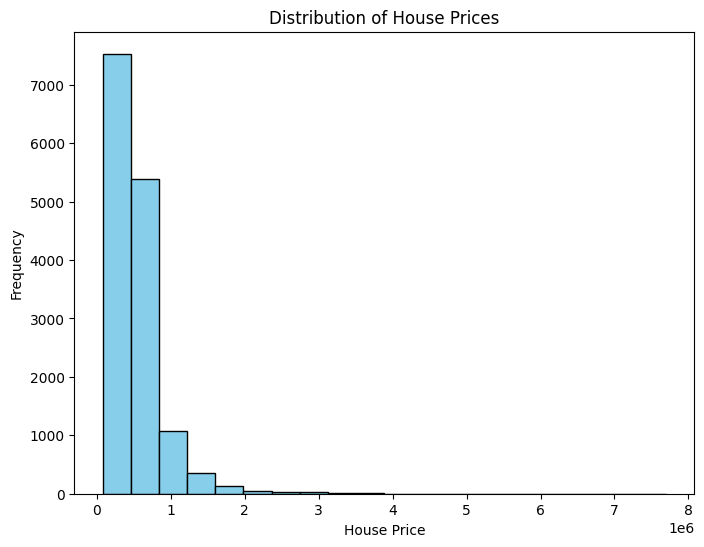

In [ ]:
# Solution
skewness = df['Price'].skew()

print("Skewness of Price Data: ", skewness)

# Interpretation
if skewness > 0:
    print("\nThe price data is positively skewed.")
elif skewness < 0:
    print("\nThe price data is negatively skewed.")
else:
    print("\nThe price data is approximately symmetric.")

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

### Interpretation
The skewness is approximately 4.27, which is strongly positive.

Therefore, the house-price distribution is right-skewed (positively skewed).

This means that:

Most houses are concentrated toward the lower/middle price range.
A relatively small number of houses have extremely high prices.
These expensive properties increase the mean substantially.

This also explains why:

Mean ≈ 538,932 > Median = 450,000

### Q4. What is the average price for each number of beedrooms?

number of bedrooms
1      308963.75
2      398547.57
3      463277.56
4      636198.81
5      775255.03
6      837581.48
7     1016543.90
8     1208454.55
9      776666.33
10     820000.00
11     520000.00
33     640000.00
Name: Price, dtype: float64


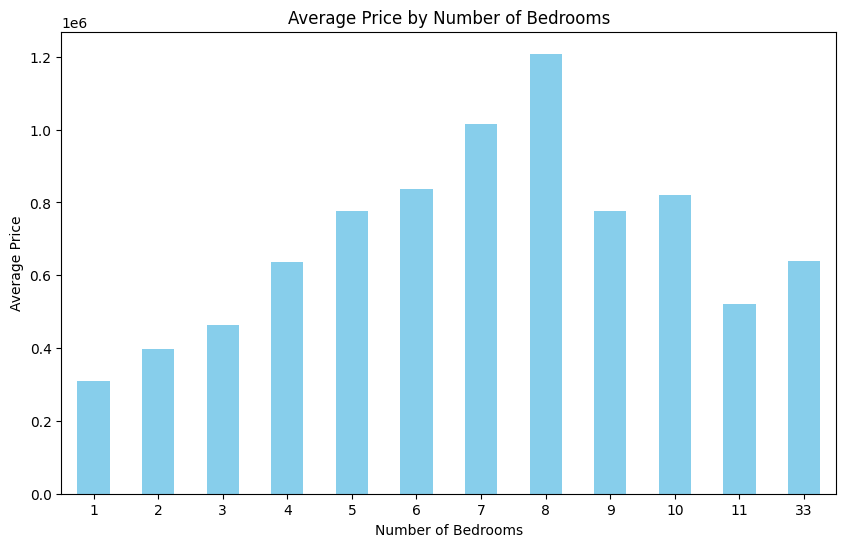

In [ ]:
# Solution
average_price_by_bedrooms = (
    df.groupby('number of bedrooms')['Price']
    .mean()
    .sort_index()
    .round(2)
)

print(average_price_by_bedrooms)

# Visualization
plt.figure(figsize=(10, 6))
average_price_by_bedrooms.plot(kind='bar', color='skyblue')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

### Interpretation
There is generally an increasing relationship between the number of bedrooms and house price.

For example:

- 1-bedroom houses average about 308,964
- 3-bedroom houses average about 463,278
- 4-bedroom houses average about 636,199
- 8-bedroom houses average about 1.21 million

However, the pattern is not perfectly increasing for the highest bedroom counts. This is likely because those categories contain relatively few properties.

The 33-bedroom category should be treated cautiously, because it is an extreme value compared with the typical bedroom counts.

### Q5. What is the relationship between living area and price? (Use : Area without Basement)

Correlation between Area and Price:  0.6152


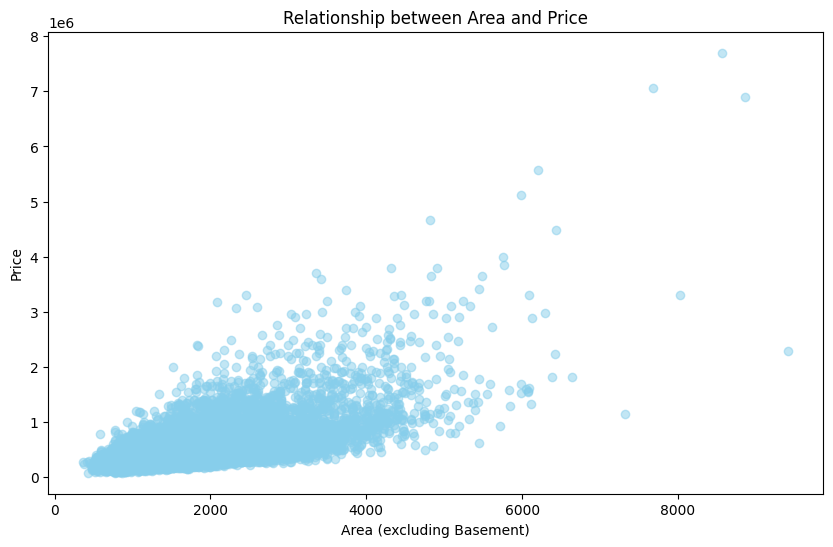

In [ ]:
# Solution
correlation = df['Area of the house(excluding basement)'].corr(df['Price']).round(4)

print("Correlation between Area and Price: ", correlation)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(
    df['Area of the house(excluding basement)'],
    df['Price'],
    alpha=0.5,
    color='skyblue'
)
plt.title('Relationship between Area and Price')
plt.xlabel('Area (excluding Basement)')
plt.ylabel('Price')
plt.show()

### Interpretation
The correlation coefficient is approximately 0.615.

This indicates a moderate positive relationship between house area excluding the basement and price.

In general:

As the living area increases, house price tends to increase.

However, the relationship is not perfect. Other factors can also affect price, such as:

- Number of bedrooms
- Number of bathrooms
- House grade
- Location
- Waterfront availability
- Condition
- Number of views
- Renovation status

### Q6. Identify any anomalies where houses have high prices but low areas

In [ ]:
# Solution

# Define thresholds
low_area_threshold = df['Area of the house(excluding basement)'].quantile(0.25)
high_price_threshold = df['Price'].quantile(0.75)

print("Low Area Threshold: ", low_area_threshold)
print("\nHigh Price Threshold: ", high_price_threshold)

# Identify anomalies
anomalies = df[
    (df['Area of the house(excluding basement)'] <= low_area_threshold) &
    (df['Price'] >= high_price_threshold)
]

print("\nAnomalies: ")
print(anomalies[
    [
        'id',
        'number of bedrooms',
        'Area of the house(excluding basement)',
        'Price',
        'Postal Code'
    ]
].head(10))

Low Area Threshold:  1200.0

High Price Threshold:  645000.0

Anomalies: 
             id  number of bedrooms  Area of the house(excluding basement)  \
101  6762815131                   4                                   1050   
174  6762814788                   2                                    930   
176  6762815227                   3                                   1160   
258  6762814540                   3                                    980   
353  6762814207                   3                                   1150   
355  6762815378                   4                                   1160   
536  6762814791                   4                                   1200   
603  6762814133                   3                                   1090   
607  6762814967                   3                                   1150   
840  6762813159                   3                                   1100   

      Price  Postal Code  
101  657100       122028  
174  675000  

### Interpretation
These houses have relatively small areas but unusually high prices.

This indicates that area alone does not determine house price.

Possible factors responsible for such high prices could include:

- Premium location
- Waterfront property
- High house grade
- Better condition
- High demand in a particular postal code
- Other property characteristics

These observations should be investigated further rather than automatically classified as errors.

### Q7. Compare average price based on number of floors and houses with or without waterfront.

In [ ]:
# Solution
average_price_floor_waterfront = (
    df.groupby(
        ["number of floors", "waterfront present"]
    )["Price"]
    .mean().round(2)
    .reset_index()
)

print(average_price_floor_waterfront)

    number of floors  waterfront present       Price
0                1.0                   0   432372.39
1                1.0                   1  1211080.95
2                1.5                   0   547616.22
3                1.5                   1  1232506.57
4                2.0                   0   635774.21
5                2.0                   1  2075931.37
6                2.5                   0  1087653.76
7                2.5                   1  3280000.00
8                3.0                   0   555809.50
9                3.0                   1  1655000.00
10               3.5                   0  1205875.00


### Interpretation
The column "waterfront present" uses:
- 0 = No waterfront
- 1 = Waterfront present

Waterfront houses generally have substantially higher average prices than non-waterfront houses across the floor categories.

For example:

- 1-floor non-waterfront: approximately 432,372
- 1-floor waterfront: approximately 1,211,081

For 2 floors:

- Non-waterfront: approximately 635,774
- Waterfront: approximately 2,075,931

Therefore, waterfront availability appears to have a strong positive association with house price.

The number of floors also affects price, but its relationship is less consistent than the waterfront effect.

### Q8. Identify the minimum and maximum house price. What does this indicate?

In [ ]:
# Solution
min_price = df['Price'].min()
max_price = df['Price'].max()

print("Minimum House Price: ", min_price)
print("\nMaximum House Price: ", max_price)

# price range
price_range = max_price - min_price
print("\nPrice Range: ", price_range)

Minimum House Price:  78000

Maximum House Price:  7700000

Price Range:  7622000


### Interpretation
The minimum house price is 78,000 whereas the maximum is 7,700,000.

This represents a very large range of 7,622,000.

The large range demonstrates that the dataset contains properties from relatively inexpensive houses to extremely expensive properties.

It also helps explain the strong positive skewness of the price variable.

### Q9. Which location (zipcode/area) has the highest average price?

In [ ]:
# Solution
average_price_by_location = (
    df.groupby('Postal Code')['Price']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(average_price_by_location)

# Find the highest
highest_average_price_location = average_price_by_location.idxmax()
highest_average_price = average_price_by_location.max()

print("\nLocation with Highest Average Price: ", highest_average_price_location)
print("\nHighest Average Price: ", highest_average_price)

# Top locations
top_locations = average_price_by_location.head(10)
print("\nTop 10 Locations with Highest Average Price: ")
print(top_locations)

Postal Code
122071    2348310.81
122048    1296414.08
122057    1188517.16
122047    1069294.89
122061     889589.56
             ...    
122070     279961.81
122039     275250.87
122066     248700.34
122072     234215.78
122056     233594.96
Name: Price, Length: 70, dtype: float64

Location with Highest Average Price:  122071

Highest Average Price:  2348310.81

Top 10 Locations with Highest Average Price: 
Postal Code
122071    2348310.81
122048    1296414.08
122057    1188517.16
122047    1069294.89
122061     889589.56
122013     885584.16
122003     850328.96
122004     839853.28
122027     829632.18
122049     803538.83
Name: Price, dtype: float64


### Interpretation
Postal Code 122071 has the highest average house price, at approximately 2.35 million.

This demonstrates that location has a substantial relationship with house prices.

Properties in certain postal codes may command significantly higher prices because of factors such as:

- Desirability of the location
- Property characteristics
- Waterfront availability
- Larger homes
- Better grades
- Local demand

### Q10. Write atleast 5 insights from your analysis.

### Solution

**Insight 1 — House prices are strongly right-skewed**

The price skewness is approximately 4.27, showing strong positive skewness.

The mean price of approximately 538,932 is higher than the median of 450,000, indicating that expensive properties pull the average upward.

**Insight 2 — Three-bedroom houses are the most common**

The most frequently occurring bedroom category is 3 bedrooms.

This suggests that three-bedroom houses represent the dominant property type in this dataset.

**Insight 3 — Larger houses generally cost more**

The correlation between area excluding basement and price is approximately 0.615.

This indicates a moderate positive relationship.

Therefore, larger houses generally command higher prices, although area is not the only pricing factor.

**Insight 4 — Waterfront properties command substantially higher prices**

Across most floor categories, waterfront houses have considerably higher average prices than non-waterfront houses.

For example, for 2-floor houses:

- No waterfront → approximately 635,774
- Waterfront → approximately 2,075,931

Therefore, waterfront availability is a major differentiating factor in property value.

**Insight 5 — Location has a strong effect on price**

Postal Code 122071 has the highest average price, approximately 2.35 million.

This indicates that property location is an important factor in determining house prices.

**Insight 6 — House prices have a very wide range**

Prices range from:

78,000 → 7,700,000

This large range indicates considerable heterogeneity in the properties represented in the dataset.

**Insight 7 — Some small houses have unusually high prices**

The analysis identified houses with approximately 1,200 units of area excluding basement but prices exceeding 645,000.

Some are priced above 1 million.

This shows that factors other than size can substantially increase property value.